In [32]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import seaborn as sns

In [5]:
PROJECT = "gridzero-489711"
DATASET = "merged_set"
TABLE = "2015_exelon_weather_raw"

query = f"""
    SELECT *
    FROM {PROJECT}.{DATASET}.{TABLE}
"""

client = bigquery.Client('gridzero-489711')
query_job = client.query(query)
result = query_job.result()
df = result.to_dataframe()

/Users/jamesla/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [16]:
df['total_output_MW'].isnull().sum()

np.int64(11703)

In [13]:
24*2*7*52

17472

In [14]:
not_null_df = df[~df['total_output_MW'].isnull()]
not_null_df

,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,...,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Nuclear,Other,Solar,Wind Offshore,Wind Onshore,total_output_MW
230,2015-01-05 19:00:00+00:00,6.4,23.5,21.6,85,0.0,0.0,0.0,1026.2,0.0,...,15569.0,0.0,420.0,1018.0,8118.0,1147.0,0.0,1113.000,3135.000,47275.000
261,2015-01-06 10:30:00+00:00,8.2,29.6,36.0,100,24.0,0.0,24.0,1018.6,0.0,...,15890.0,0.0,569.0,911.0,8127.0,1049.0,205.0,2454.000,3009.000,43048.000
262,2015-01-06 11:00:00+00:00,9.0,31.4,37.4,98,49.0,2.0,47.0,1018.2,0.0,...,15877.0,0.0,446.0,999.0,8126.0,1123.0,289.0,2507.000,3001.000,42964.000
615,2015-01-13 19:30:00+00:00,4.3,26.0,27.7,93,0.0,0.0,0.0,1003.2,0.0,...,16037.0,0.0,1189.0,1023.0,8512.0,1097.0,0.0,2191.000,3686.000,46016.000
620,2015-01-13 22:00:00+00:00,3.9,29.3,33.8,56,0.0,0.0,0.0,1003.9,0.0,...,14329.0,0.0,382.0,892.0,8549.0,1097.0,0.0,2684.000,3782.000,36934.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196218,2026-03-11 21:00:00+00:00,7.6,26.0,29.9,50,0.0,0.0,0.0,1018.0,0.0,...,0.0,0.0,1220.0,444.0,3003.0,396.0,0.0,10276.025,9032.398,32453.423
196219,2026-03-11 21:30:00+00:00,7.6,26.0,29.9,50,0.0,0.0,0.0,1018.0,0.0,...,0.0,0.0,993.0,442.0,3003.0,387.0,0.0,10034.962,8973.533,31433.495
196220,2026-03-11 22:00:00+00:00,7.3,26.4,30.2,86,0.0,0.0,0.0,1018.3,0.0,...,0.0,0.0,353.0,444.0,3095.0,689.0,0.0,10001.928,8867.501,31148.429
196221,2026-03-11 22:30:00+00:00,7.3,26.4,30.2,86,0.0,0.0,0.0,1018.3,0.0,...,0.0,0.0,103.0,438.0,3094.0,487.0,0.0,10362.704,8830.918,30511.622


In [17]:
from sklearn.impute import SimpleImputer

In [18]:
df.columns

Index(['datetime', 'temperature_2m_c', 'wind_speed_100m_ms',
       'wind_gusts_10m_ms', 'cloud_cover_pct', 'shortwave_radiation_wm2',
       'direct_radiation_wm2', 'diffuse_radiation_wm2', 'pressure_msl_hpa',
       'snowfall_cm', 'rain_mm', 'precipitation_mm', 'Biomass', 'Fossil Gas',
       'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage',
       'Hydro Run-of-river and poundage', 'Nuclear', 'Other', 'Solar',
       'Wind Offshore', 'Wind Onshore', 'total_output_MW'],
      dtype='object')

In [20]:
X = df[['Biomass', 'Fossil Gas',
       'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage',
       'Hydro Run-of-river and poundage', 'Nuclear', 'Other', 'Solar',
       'Wind Offshore', 'Wind Onshore', 'total_output_MW']]

In [29]:
imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=-10000)

X = imputer.fit_transform(X)

In [35]:
df2 = pd.DataFrame(X)
df2

,0,1,2,3,4,5,6,7,8,9,10,11
0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.000,-10000.000,-10000.000
1,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.000,-10000.000,-10000.000
2,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.000,-10000.000,-10000.000
3,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.000,-10000.000,-10000.000
4,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.000,-10000.000,-10000.000
...,...,...,...,...,...,...,...,...,...,...,...,...
196218,1715.0,6367.0,0.0,0.0,1220.0,444.0,3003.0,396.0,0.0,10276.025,9032.398,32453.423
196219,1719.0,5881.0,0.0,0.0,993.0,442.0,3003.0,387.0,0.0,10034.962,8973.533,31433.495
196220,1813.0,5885.0,0.0,0.0,353.0,444.0,3095.0,689.0,0.0,10001.928,8867.501,31148.429
196221,1883.0,5313.0,0.0,0.0,103.0,438.0,3094.0,487.0,0.0,10362.704,8830.918,30511.622


In [45]:
df2[:17472]

,0,1,2,3,4,5,6,7,8,9,10,11
0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0
1,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0
2,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0
3,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0
4,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0,-10000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
17467,-10000.0,11827.0,4982.0,0.0,452.0,966.0,7963.0,2040.0,0.0,2960.0,1392.0,32582.0
17468,-10000.0,10921.0,4590.0,0.0,388.0,970.0,7753.0,2043.0,0.0,3034.0,1350.0,31049.0
17469,-10000.0,9132.0,4350.0,0.0,675.0,979.0,7680.0,2044.0,0.0,3018.0,1397.0,29275.0
17470,-10000.0,7959.0,4269.0,0.0,286.0,978.0,7688.0,2043.0,0.0,2998.0,1465.0,27686.0


In [40]:
df2[11]

0        -10000.000
1        -10000.000
2        -10000.000
3        -10000.000
4        -10000.000
            ...    
196218    32453.423
196219    31433.495
196220    31148.429
196221    30511.622
196222    30607.883
Name: 11, Length: 196223, dtype: float64

<Axes: xlabel='None', ylabel='11'>

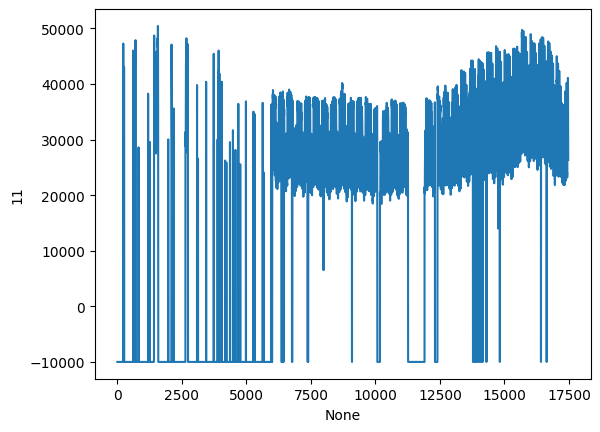

In [50]:
sns.lineplot(x=df2[:17472].index, y=df2[11][:17472])

<Axes: xlabel='None', ylabel='11'>

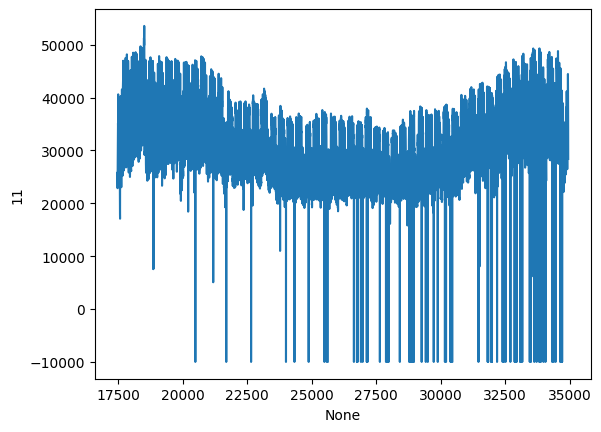

In [54]:
sns.lineplot(x=df2[17472:17472*2].index, y=df2[11][17472:17472*2])

<Axes: xlabel='None', ylabel='11'>

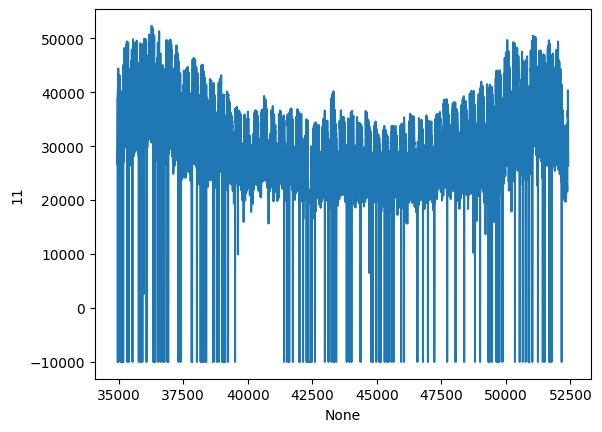

In [55]:
sns.lineplot(x=df2[17472*2:17472*3].index, y=df2[11][17472*2:17472*3])

<Axes: xlabel='None', ylabel='11'>

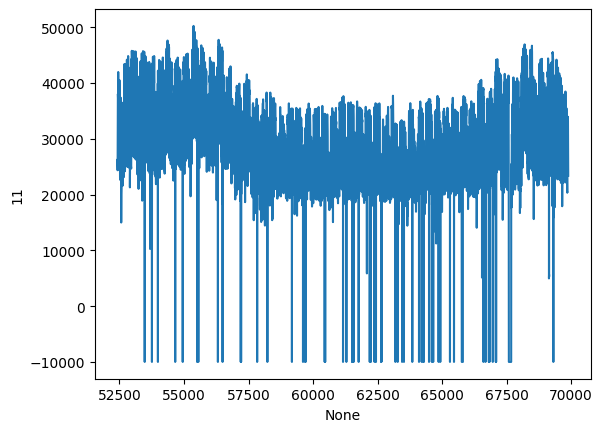

In [56]:
sns.lineplot(x=df2[17472*3:17472*4].index, y=df2[11][17472*3:17472*4])

<Axes: xlabel='None', ylabel='11'>

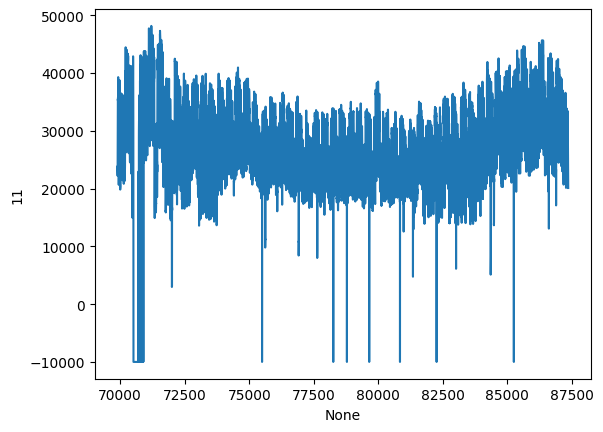

In [57]:
sns.lineplot(x=df2[17472*4:17472*5].index, y=df2[11][17472*4:17472*5])

<Axes: xlabel='None', ylabel='11'>

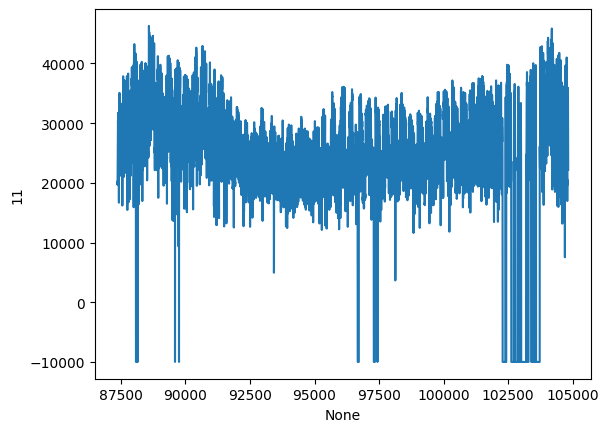

In [58]:
sns.lineplot(x=df2[17472*5:17472*6].index, y=df2[11][17472*5:17472*6])

In [59]:
import pandas as pd
from datetime import datetime, timedelta
import requests


def fetch_exelon(start_date, end_date):
    """
    fetch data within specifite dates from Exelon AGBT API and returns it as a pandas dataframe
    """
    url = "https://data.elexon.co.uk/bmrs/api/v1/generation/actual/per-type"

    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")

    dfs = []

    while start <= end:

        chunk_end = min(start + timedelta(days=6), end)

        params = {
            "from": start.strftime("%Y-%m-%d"),
            "to": chunk_end.strftime("%Y-%m-%d"),
            "settlementPeriodFrom": 1,
            "settlementPeriodTo": 50,
            "format": "json"
        }

        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()

        data = response.json().get("data", [])

        if data:
            df_raw = pd.DataFrame(data)
            df_exploded = df_raw.explode('data').reset_index(drop=True)
            df_normalized = pd.json_normalize(df_exploded['data'])
            df_normalized['startTime'] = df_exploded['startTime'].values
            dfs.append(df_normalized)

        start = chunk_end + timedelta(days=1)

    if not dfs:
        return pd.DataFrame(columns=["startTime", "psrType", "quantity"])

    return pd.concat(dfs, ignore_index=True)


def exelon_preproc(df):
    """
    preprocessing exelon dataframe:
    convert StartTime column from object into datetime, pivot PsrType (fuel type) column
    into their own columns with their individual generation quantities,
    """
    df['startTime'] = pd.to_datetime(df['startTime']).dt.tz_convert(None)
    df_pivot = df.pivot_table(
        index='startTime',
        columns='psrType',
        values='quantity',
        aggfunc='sum'
    )

    df_pivot['TotalOutput-MW'] = df_pivot.sum(axis=1)

    return df_pivot


In [60]:
# imports required
from google.cloud import bigquery
import pandas as pd
import requests


def fetch_weather(start_date, end_date, latitude=51.5, longitude=-0.1):
    '''fetch api data from open-meteo archive,
    returns selected parameters hourly for London (based on long and lat).
    Dates in string format. See weather_data_notes.txt for information on selected params.'''

    url = 'https://archive-api.open-meteo.com/v1/archive'

    selected_params = {
        'latitude': latitude,
        'longitude': longitude,
        'start_date': start_date,
        'end_date': end_date,
        'timezone': 'UTC',
        'hourly': [
            'temperature_2m',
            'wind_speed_100m',
            'wind_gusts_10m',
            'cloud_cover',
            'shortwave_radiation',
            'direct_radiation',
            'diffuse_radiation',
            'pressure_msl',
            'snowfall',
            'rain',
            'precipitation'
        ]
    }

    response = requests.get(url, params=selected_params, timeout=30)
    response.raise_for_status()

    data = response.json()

    if "hourly" not in data:
        raise ValueError(f"Unexpected API response:{data}")

    df = pd.DataFrame(data["hourly"])

    return df


def weather_preproc(df):
    ''' preprocess weather dataframe, resample, rename, check quality'''
    # datetime and set index
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')

    # sample half hourly
    df = df.resample('30min').ffill()

    # reset index and rename to datetime
    df = df.reset_index()
    df = df.rename(columns={'time': 'datetime'})

    # rename columns w/ units
    df = df.rename(columns={
        'temperature_2m': 'temperature_2m_c',
        'wind_speed_100m': 'wind_speed_100m_ms',
        'wind_gusts_10m': 'wind_gusts_10m_ms',
        'cloud_cover': 'cloud_cover_pct',
        'shortwave_radiation': 'shortwave_radiation_wm2',
        'direct_radiation': 'direct_radiation_wm2',
        'diffuse_radiation': 'diffuse_radiation_wm2',
        'pressure_msl': 'pressure_msl_hpa',
        'snowfall': 'snowfall_cm',
        'rain': 'rain_mm',
        'precipitation': 'precipitation_mm'
    })

    return df


In [61]:
weather_df = fetch_weather('2025-01-01', '2025-03-01')
weather_df = weather_preproc(weather_df)

In [62]:
exelon_df = fetch_exelon('2025-01-01', '2025-03-01')
exelon_df = exelon_preproc(exelon_df)

In [63]:
weather_df

,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,rain_mm,precipitation_mm
0,2025-01-01 00:00:00,10.5,48.0,55.1,100,0.0,0.0,0.0,1014.2,0.0,0.0,0.0
1,2025-01-01 00:30:00,10.5,48.0,55.1,100,0.0,0.0,0.0,1014.2,0.0,0.0,0.0
2,2025-01-01 01:00:00,11.1,46.3,58.3,100,0.0,0.0,0.0,1013.1,0.0,0.0,0.0
3,2025-01-01 01:30:00,11.1,46.3,58.3,100,0.0,0.0,0.0,1013.1,0.0,0.0,0.0
4,2025-01-01 02:00:00,11.1,43.6,60.5,100,0.0,0.0,0.0,1012.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2874,2025-03-01 21:00:00,3.7,9.0,8.3,100,0.0,0.0,0.0,1036.3,0.0,0.0,0.0
2875,2025-03-01 21:30:00,3.7,9.0,8.3,100,0.0,0.0,0.0,1036.3,0.0,0.0,0.0
2876,2025-03-01 22:00:00,3.2,8.9,5.4,95,0.0,0.0,0.0,1036.7,0.0,0.0,0.0
2877,2025-03-01 22:30:00,3.2,8.9,5.4,95,0.0,0.0,0.0,1036.7,0.0,0.0,0.0


In [64]:
exelon_df

psrType,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Nuclear,Other,Solar,Wind Offshore,Wind Onshore,TotalOutput-MW
startTime,,,,,,,,,,,,
2025-01-01 00:00:00,880.0,3607.0,0.0,0.0,0.0,736.0,5065.0,183.0,0.0,11444.531,9113.028,31028.559
2025-01-01 00:30:00,1078.0,3854.0,0.0,0.0,0.0,745.0,5063.0,290.0,0.0,11138.565,8969.868,31138.433
2025-01-01 01:00:00,1104.0,3867.0,0.0,0.0,0.0,746.0,5056.0,333.0,0.0,10788.770,8931.922,30826.692
2025-01-01 01:30:00,1109.0,3726.0,0.0,0.0,0.0,746.0,5060.0,238.0,0.0,10519.534,8810.976,30209.510
2025-01-01 02:00:00,1064.0,3682.0,0.0,0.0,0.0,747.0,5056.0,277.0,0.0,10706.056,8456.386,29988.442
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-01 21:30:00,3040.0,14537.0,0.0,0.0,150.0,644.0,4202.0,384.0,0.0,2348.448,2157.832,27463.280
2025-03-01 22:00:00,3032.0,12731.0,0.0,0.0,0.0,563.0,4195.0,387.0,0.0,2222.523,2184.719,25315.242
2025-03-01 22:30:00,3036.0,11363.0,0.0,0.0,0.0,546.0,4202.0,319.0,0.0,2386.018,2308.548,24160.566


In [69]:
df = (weather_df.merge(exelon_df, left_on='datetime', right_on='startTime', how='left'))
df

,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,...,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Nuclear,Other,Solar,Wind Offshore,Wind Onshore,TotalOutput-MW
0,2025-01-01 00:00:00,10.5,48.0,55.1,100,0.0,0.0,0.0,1014.2,0.0,...,0.0,0.0,0.0,736.0,5065.0,183.0,0.0,11444.531,9113.028,31028.559
1,2025-01-01 00:30:00,10.5,48.0,55.1,100,0.0,0.0,0.0,1014.2,0.0,...,0.0,0.0,0.0,745.0,5063.0,290.0,0.0,11138.565,8969.868,31138.433
2,2025-01-01 01:00:00,11.1,46.3,58.3,100,0.0,0.0,0.0,1013.1,0.0,...,0.0,0.0,0.0,746.0,5056.0,333.0,0.0,10788.770,8931.922,30826.692
3,2025-01-01 01:30:00,11.1,46.3,58.3,100,0.0,0.0,0.0,1013.1,0.0,...,0.0,0.0,0.0,746.0,5060.0,238.0,0.0,10519.534,8810.976,30209.510
4,2025-01-01 02:00:00,11.1,43.6,60.5,100,0.0,0.0,0.0,1012.0,0.0,...,0.0,0.0,0.0,747.0,5056.0,277.0,0.0,10706.056,8456.386,29988.442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2874,2025-03-01 21:00:00,3.7,9.0,8.3,100,0.0,0.0,0.0,1036.3,0.0,...,0.0,0.0,147.0,645.0,4191.0,575.0,0.0,2385.803,2236.351,28732.154
2875,2025-03-01 21:30:00,3.7,9.0,8.3,100,0.0,0.0,0.0,1036.3,0.0,...,0.0,0.0,150.0,644.0,4202.0,384.0,0.0,2348.448,2157.832,27463.280
2876,2025-03-01 22:00:00,3.2,8.9,5.4,95,0.0,0.0,0.0,1036.7,0.0,...,0.0,0.0,0.0,563.0,4195.0,387.0,0.0,2222.523,2184.719,25315.242
2877,2025-03-01 22:30:00,3.2,8.9,5.4,95,0.0,0.0,0.0,1036.7,0.0,...,0.0,0.0,0.0,546.0,4202.0,319.0,0.0,2386.018,2308.548,24160.566
